In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)


df = pd.read_csv("student_performance.csv")
df.head()

df.groupby("result")[["study_hours","attendance","assignments"]].mean()

Environment ready!
NumPy: 2.5.2
pandas: 3.0.6
scikit-learn: 1.9.1


,study_hours,attendance,assignments
result,,,
Fail,2.750000,61.416667,3.916667
Pass,6.605556,86.500000,8.611111


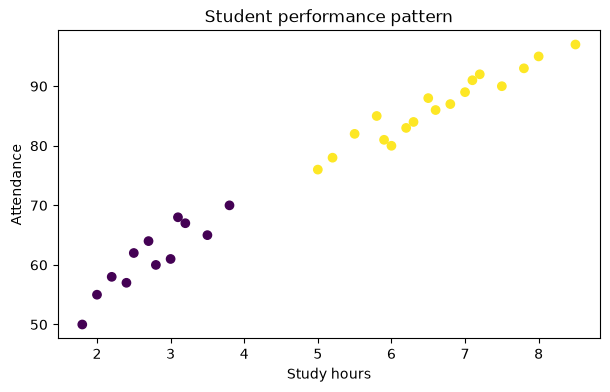

X shape: (30, 3)
y shape: (30,)
Training rows: 24
Testing rows : 6
Model trained!
Test accuracy: 1.0
Predictions:
['Fail' 'Pass' 'Pass' 'Pass' 'Pass' 'Fail']
X-test:
    study_hours  attendance  assignments
9           3.5          65            5
12          6.8          87            9
6           8.0          95           10
2           5.8          85            8
8           5.2          78            7
16          3.2          67            5


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

df = pd.read_csv("student_performance.csv")

colors = df["result"].map({"Fail": 0, "Pass": 1})

plt.figure(figsize=(7, 4))

plt.scatter(
    df["study_hours"],
    df["attendance"],
    c=colors
)

plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")

plt.show()


X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)

model.fit(X_train, y_train)

print("Model trained!")
print("Test accuracy:", model.score(X_test, y_test))

predictions = model.predict(X_test)

print("Predictions:")
print(predictions)
print("X-test:")
print(X_test)


In [38]:
accuracy= accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 1.0


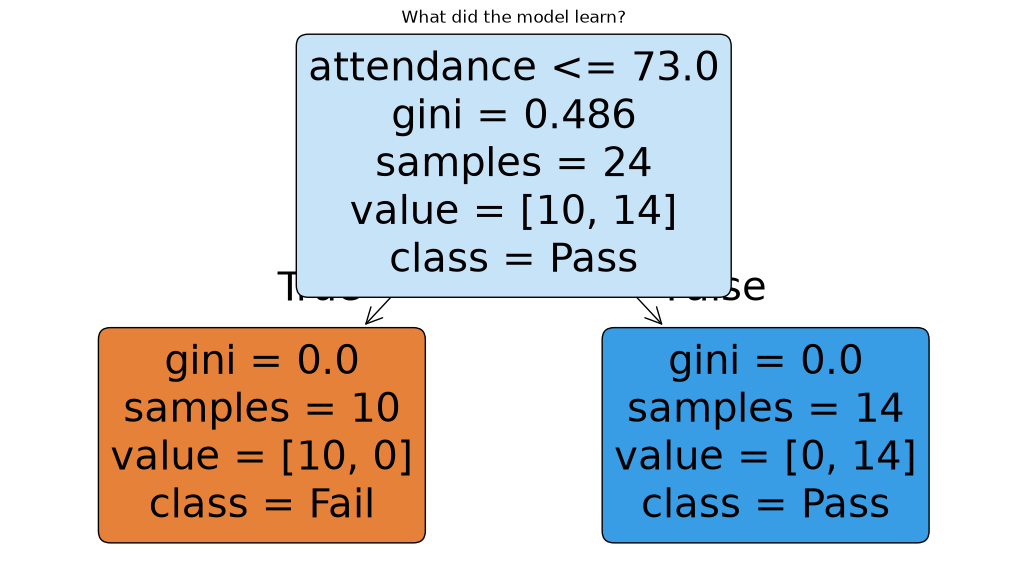

In [39]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()